In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

In [2]:
btc = yf.download("BTC-USD", start="2018-01-01")

data = btc[['Close']].copy()

data.rename(columns={"Close":"Price"}, inplace=True)

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price              Price
Ticker           BTC-USD
Date                    
2018-01-01  13657.200195
2018-01-02  14982.099609
2018-01-03  15201.000000
2018-01-04  15599.200195
2018-01-05  17429.500000


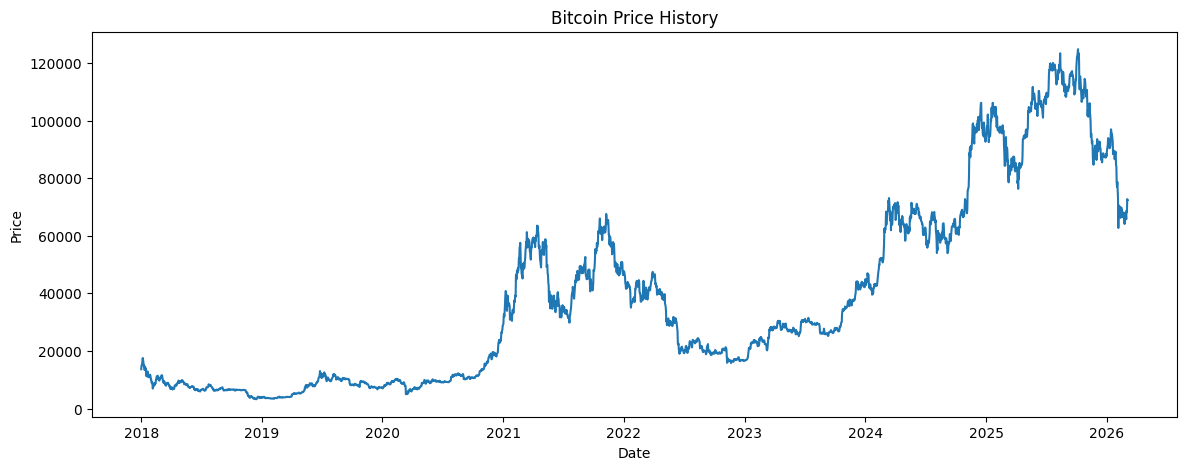

In [3]:
plt.figure(figsize=(14,5))

plt.plot(data["Price"])

plt.title("Bitcoin Price History")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [6]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2926, 60, 1)
y shape: (2926, 1)


In [8]:
# For time series we split chronologically.
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [12]:
# 60 day sequence
#       ↓
# LSTM (50 neurons)
#       ↓
# Dropout
#       ↓
# LSTM (50 neurons)
#       ↓
# Dense Layer
#       ↓
# Predicted Price


model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=1))

In [13]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 9.5828e-04 - val_loss: 0.0032
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 8.8083e-04 - val_loss: 0.0021
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.3703e-04 - val_loss: 0.0012
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 7.0405e-04 - val_loss: 0.0026
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 7.6890e-04 - val_loss: 0.0015
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.4249e-04 - val_loss: 0.0013
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.8133e-04 - val_loss: 9.6271e-04
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 5.6227e-04 - val_loss: 8.5178e-04
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.4615e-04 - val_loss: 8.0847e-04
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 5.3672e-04 - val_loss: 0.0016
Epoch 12/20

In [15]:
predictions = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [16]:
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

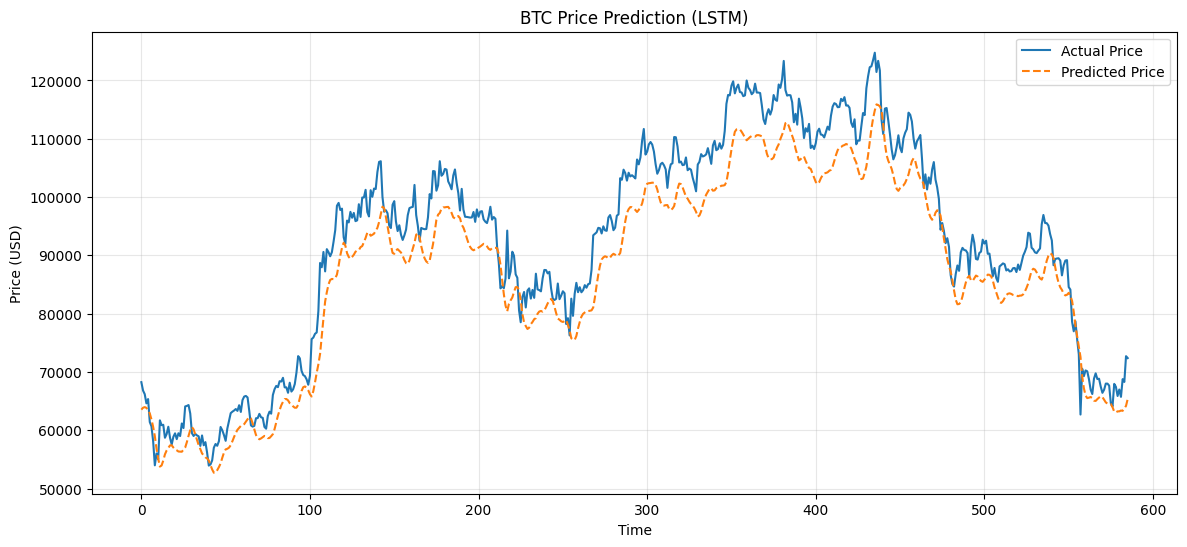

In [17]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price", linestyle="--")

plt.title("BTC Price Prediction (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5376.749740027731
RMSE: 6096.165810178657


### Forecast the next 30 days using the trained LSTM.

In [22]:
last_sequence = scaled_data[-sequence_length:]

In [23]:
last_sequence = last_sequence.reshape(1, sequence_length, 1)

In [25]:
future_days = 30

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    # predict next day
    next_price = model.predict(current_sequence)[0][0]

    future_predictions.append(next_price)

    # update sequence
    next_price_reshaped = np.array(next_price).reshape(1,1,1)
    
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], next_price_reshaped),
        axis=1
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

In [26]:
#convert to actual price
future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions = scaler.inverse_transform(future_predictions)

In [28]:
# Create Future Dates
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

In [29]:
future_prices = pd.Series(
    future_predictions.flatten(),
    index=future_dates
)

print(future_prices)

2026-03-06    66669.835938
2026-03-07    66765.789062
2026-03-08    66262.765625
2026-03-09    65429.007812
2026-03-10    64419.511719
2026-03-11    63325.226562
2026-03-12    62200.054688
2026-03-13    61076.195312
2026-03-14    59972.667969
2026-03-15    58900.324219
2026-03-16    57864.750000
2026-03-17    56868.121094
2026-03-18    55910.390625
2026-03-19    54990.035156
2026-03-20    54104.722656
2026-03-21    53251.582031
2026-03-22    52427.554688
2026-03-23    51629.632812
2026-03-24    50854.929688
2026-03-25    50100.812500
2026-03-26    49364.929688
2026-03-27    48645.246094
2026-03-28    47940.035156
2026-03-29    47247.863281
2026-03-30    46567.558594
2026-03-31    45898.175781
2026-04-01    45238.992188
2026-04-02    44589.433594
2026-04-03    43949.042969
2026-04-04    43317.496094
Freq: D, dtype: float32


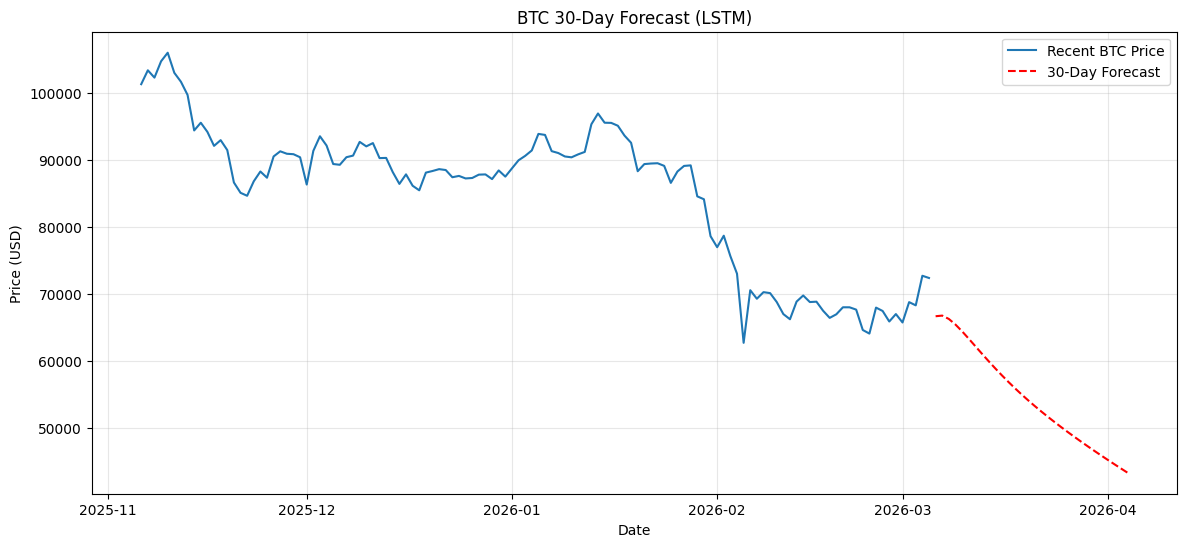

In [30]:
plt.figure(figsize=(14,6))

plt.plot(data["Price"].tail(120), label="Recent BTC Price")

plt.plot(
    future_prices,
    label="30-Day Forecast",
    linestyle="--",
    color="red"
)

plt.title("BTC 30-Day Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

## ADD MORE INDICATORS

In [83]:
btc = yf.download("BTC-USD", start="2018-01-01")
btc.columns = btc.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [95]:
data = btc[['Close','Volume']].copy()

data.rename(columns={"Close":"Price"}, inplace=True)

In [96]:
# Moving averages
data["MA10"] = data["Price"].rolling(10).mean()
data["MA30"] = data["Price"].rolling(30).mean()

data["Volatility"] = data["Price"].rolling(10).std()

data["Momentum"] = data["Price"] - data["Price"].shift(10)

data = data.dropna()

print(data.head())

Price              Price       Volume          MA10          MA30  \
Date                                                                
2018-01-30  10106.299805   8637859840  11181.980176  13181.040039   
2018-01-31  10221.099609   8041160192  11044.080176  13066.503353   
2018-02-01   9170.540039   9959400448  10867.994141  12872.784701   
2018-02-02   8830.750000  12726899712  10664.229102  12660.443034   
2018-02-03   9174.910156   7263790080  10445.780078  12446.300033   

Price        Volatility     Momentum  
Date                                  
2018-01-30   468.549610 -2792.900391  
2018-01-31   530.634017 -1379.000000  
2018-02-01   797.325051 -1760.860352  
2018-02-02  1025.058629 -2037.650391  
2018-02-03  1091.090931 -2184.490234  


In [97]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(2957, 6)


In [98]:
# Create Multivariate Sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i,0])  # predict price

X = np.array(X)
y = np.array(y)

print(X.shape)

(2897, 60, 6)


In [99]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

C:\Users\Hexi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [101]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [102]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [103]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop]
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0040 - val_loss: 0.0028
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0011 - val_loss: 0.0039
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.7012e-04 - val_loss: 0.0051
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.9933e-04 - val_loss: 0.0039
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 6.8658e-04 - val_loss: 0.0016
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 6.2349e-04 - val_loss: 0.0025
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.3691e-04 - val_loss: 0.0043
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 5.0368e-04 - val_loss: 0.0029
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.0022e-04 - val_loss: 0.0015
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.5907e-04 - val_loss: 0.0029
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.5741e-04 - val_loss: 0.0123
Epoch 12/50
73/73 ━━━━━━━━━

In [104]:
predictions = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [105]:
pred_dummy = np.zeros((len(predictions), scaled_data.shape[1]))
pred_dummy[:,0] = predictions.flatten()

predictions = scaler.inverse_transform(pred_dummy)[:,0]

y_dummy = np.zeros((len(y_test), scaled_data.shape[1]))
y_dummy[:,0] = y_test

y_test_actual = scaler.inverse_transform(y_dummy)[:,0]

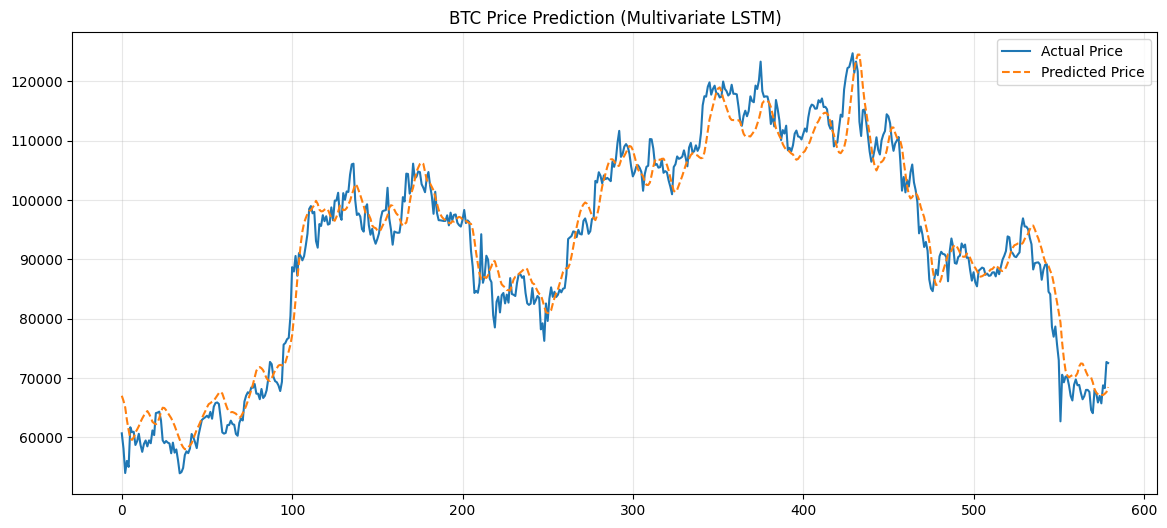

In [106]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual,label="Actual Price")
plt.plot(predictions,label="Predicted Price",linestyle="--")

plt.title("BTC Price Prediction (Multivariate LSTM)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [107]:
# PREDICT NEXT 30 DAYS

last_sequence = scaled_data[-sequence_length:]

last_sequence = last_sequence.reshape(1, sequence_length, scaled_data.shape[1])

In [108]:
last_sequence

array([[[0.74595909, 0.14496069, 0.72892619, 0.74959974, 0.26496295,
         0.67807347],
        [0.74469569, 0.14224321, 0.73395372, 0.75057201, 0.30576728,
         0.66427308],
        [0.72477254, 0.11647261, 0.73689906, 0.7507674 , 0.29534501,
         0.61249592],
        [0.72246066, 0.11338508, 0.74019792, 0.75028041, 0.26215225,
         0.62128695],
        [0.71823057, 0.10166016, 0.74196482, 0.74983929, 0.2438542 ,
         0.58319185],
        [0.71718993, 0.02718684, 0.74440595, 0.7492177 , 0.19756889,
         0.59995801],
        [0.72081755, 0.04091979, 0.74618346, 0.74938067, 0.16844861,
         0.58345568],
        [0.72382565, 0.11039574, 0.74724234, 0.74964229, 0.15715635,
         0.56558575],
        [0.75780304, 0.14957007, 0.75124492, 0.75173307, 0.21164014,
         0.63878627],
        [0.77103216, 0.16569392, 0.75592378, 0.75480769, 0.28558907,
         0.65560285],
        [0.75969091, 0.14412733, 0.75733921, 0.75706247, 0.30620799,
         0.57445208],

In [109]:
future_days = 30
future_prices = []

temp_data = data.copy()

for _ in range(future_days):

    scaled_temp = scaler.transform(temp_data.iloc[-sequence_length:])

    current_sequence = scaled_temp.reshape(
        1,
        sequence_length,
        scaled_data.shape[1]
    )

    pred_scaled = model.predict(current_sequence, verbose=0)[0][0]

    dummy = np.zeros((1, scaled_data.shape[1]))
    dummy[0,0] = pred_scaled

    pred_price = scaler.inverse_transform(dummy)[0,0]

    future_prices.append(pred_price)

    new_row = temp_data.iloc[-1].copy()
    new_row["Price"] = pred_price

    temp_data = pd.concat([temp_data, pd.DataFrame([new_row])], ignore_index=True)

    temp_data["MA10"] = temp_data["Price"].rolling(10).mean()
    temp_data["MA30"] = temp_data["Price"].rolling(30).mean()
    temp_data["Volatility"] = temp_data["Price"].rolling(10).std()
    temp_data["Momentum"] = temp_data["Price"] - temp_data["Price"].shift(10)

    temp_data = temp_data.bfill()

In [110]:
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

future_prices = pd.Series(future_prices, index=future_dates)

print(future_prices)

2026-03-06    69758.832182
2026-03-07    70766.305681
2026-03-08    71354.038391
2026-03-09    71839.037748
2026-03-10    72426.031682
2026-03-11    72974.051548
2026-03-12    73615.374507
2026-03-13    74046.971930
2026-03-14    74447.323464
2026-03-15    74481.473758
2026-03-16    74426.775345
2026-03-17    74586.242368
2026-03-18    74752.974025
2026-03-19    74888.872638
2026-03-20    74978.655679
2026-03-21    75003.448141
2026-03-22    74956.289591
2026-03-23    74826.945806
2026-03-24    74629.612879
2026-03-25    74374.191860
2026-03-26    74096.795869
2026-03-27    73820.131411
2026-03-28    73537.600201
2026-03-29    73247.369784
2026-03-30    72950.599024
2026-03-31    72649.859153
2026-04-01    72349.054095
2026-04-02    72052.594780
2026-04-03    71765.630913
2026-04-04    71492.435806
Freq: D, dtype: float64


In [111]:
future_prices = pd.Series(
    future_prices,
    index=future_dates
)

print(future_prices)

2026-03-06    69758.832182
2026-03-07    70766.305681
2026-03-08    71354.038391
2026-03-09    71839.037748
2026-03-10    72426.031682
2026-03-11    72974.051548
2026-03-12    73615.374507
2026-03-13    74046.971930
2026-03-14    74447.323464
2026-03-15    74481.473758
2026-03-16    74426.775345
2026-03-17    74586.242368
2026-03-18    74752.974025
2026-03-19    74888.872638
2026-03-20    74978.655679
2026-03-21    75003.448141
2026-03-22    74956.289591
2026-03-23    74826.945806
2026-03-24    74629.612879
2026-03-25    74374.191860
2026-03-26    74096.795869
2026-03-27    73820.131411
2026-03-28    73537.600201
2026-03-29    73247.369784
2026-03-30    72950.599024
2026-03-31    72649.859153
2026-04-01    72349.054095
2026-04-02    72052.594780
2026-04-03    71765.630913
2026-04-04    71492.435806
Freq: D, dtype: float64


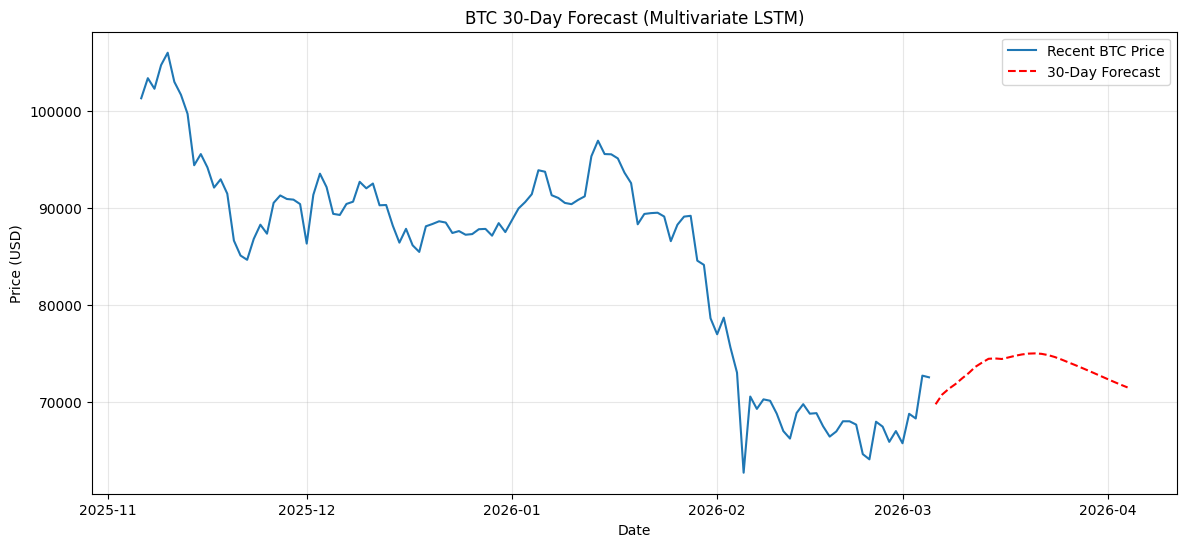

In [112]:
plt.figure(figsize=(14,6))

plt.plot(data["Price"].tail(120), label="Recent BTC Price")

plt.plot(
    future_prices,
    label="30-Day Forecast",
    linestyle="--",
    color="red"
)

plt.title("BTC 30-Day Forecast (Multivariate LSTM)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()